In [21]:
#Carregando bibliotecas e datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

users = pd.read_csv(
    "../data/processed/users_clean.csv"
)

user_plan = pd.read_csv(
    "../data/processed/user_plan_clean.csv",
    parse_dates=["data_inicio"]
)

user_app = pd.read_csv(
    "../data/processed/user_app_clean.csv",
    parse_dates=["checkin"]
)

activities = pd.read_csv(
    "../data/processed/activities_clean.csv",
    parse_dates=["date"]
)

weekly_visits = pd.read_csv(
    "../data/processed/weekly_visits_clean.csv"
)

challenges = pd.read_csv(
    "../data/processed/challenges_clean.csv",
    parse_dates=["data_inicio", "data_fim"]
)

desafio_usuario = pd.read_csv(
    "../data/processed/desafio_usuario_clean.csv",
    parse_dates=["data_desafio"]
)

In [22]:
#Criando dicionário dos datasets
datasets = {
    'users': users,
    'user_plan': user_plan,
    'user_app': user_app,
    'activities': activities,
    'weekly_visits': weekly_visits,
    'challenges': challenges,
    'desafio_usuario': desafio_usuario
}

Hipótese 1: *Desafios aumentam engajamento:*

    1. Usuários que participam de desafios (variando de acordo com o desafio) apresentam maior nível de atividade física do que usuários que não participam, a depender do tempo semanal de realização da atividade.

        Métricas associadas:
            Média de steps por usuário;
            Média de calories_burned;
            Atividades que apresentam médias maiores de steps e calorias queimadas;
            Semanas que apresentam mais densidade de participações e calorias;
            Número de atividades registradas.

In [23]:
#Hipótese 1:

##Será usado como unidade de análise o usuário em si, e não a linha de atividade

###Agregando comportamento por usuário
df_user = activities.groupby('user_id').agg({
   'steps':'mean',
   'calories_burned':'mean',
   'activity_id':'count' 
}).reset_index()

###Renomeando as colunas
df_user.rename(columns={
    'steps':'steps_mean',
    'calories_burned':'calories_mean',
    'activity_id':'n_activities'
}, inplace=True)

In [24]:
#Adicionando a variável de participação
participants = desafio_usuario['user_id'].unique()

users['participa'] = users['user_id'].isin(participants)

#Dando Merge
df_user = df_user.merge(
    users[['user_id', 'participa', 'age_group', 'gender', 'distance_to_gym']],
    on='user_id'
)

#Merge de atividades
df_activities_full = activities.merge(
    users[['user_id', 'participa', 'age_group', 'gender']],
    on='user_id',
    how='left'
)

In [25]:
#Contagem do grupo de participantes
df_user['participa'].value_counts()

participa
False    600
True     400
Name: count, dtype: int64

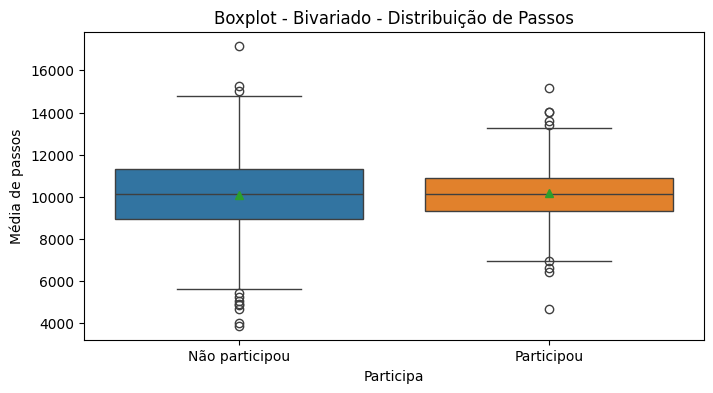

In [26]:
#Entendendo a distribuição dos valores de passos
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

df_user['participa_label'] = df_user['participa'].map({True: 'Participou', False: 'Não participou'})

plt.figure(figsize=(8,4))

sns.boxplot(data=df_user,
    x='participa',
    y='steps_mean',
    showmeans=True,
    hue='participa_label',
    palette='tab10',
    legend=False
)

plt.xlabel('Participa')
plt.ylabel('Média de passos')
plt.xticks([0,1], ['Não participou', 'Participou'])

plt.title('Boxplot - Bivariado - Distribuição de Passos')

file_path = '../outputs/EDA_Bivariate/boxplot_bivariado_passos.png'

plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

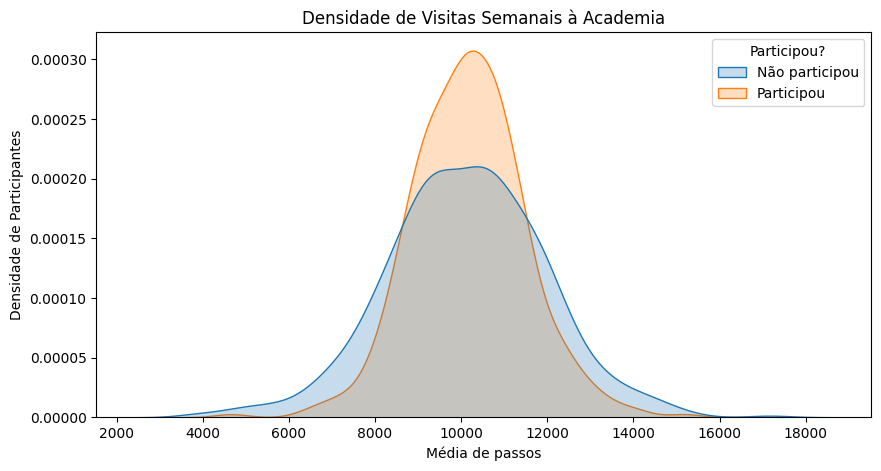

In [27]:
#KDE para densidade de passos e participantes
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

plt.figure(figsize=(10,5))

sns.kdeplot(data=df_user,
        x='steps_mean',
        hue='participa_label',
        fill=True,
        common_norm=False
)
sns.move_legend(plt.gca(), 'upper right', title='Participou?')

plt.title('Densidade de Visitas Semanais à Academia')
plt.xlabel('Média de passos')
plt.ylabel('Densidade de Participantes')

file_path = "../outputs/EDA_Bivariate/kdeplot_Densidade_de_Passos_Semanais_a_Academia.png"

plt.savefig(file_path ,bbox_inches='tight')
plt.show()
plt.close()

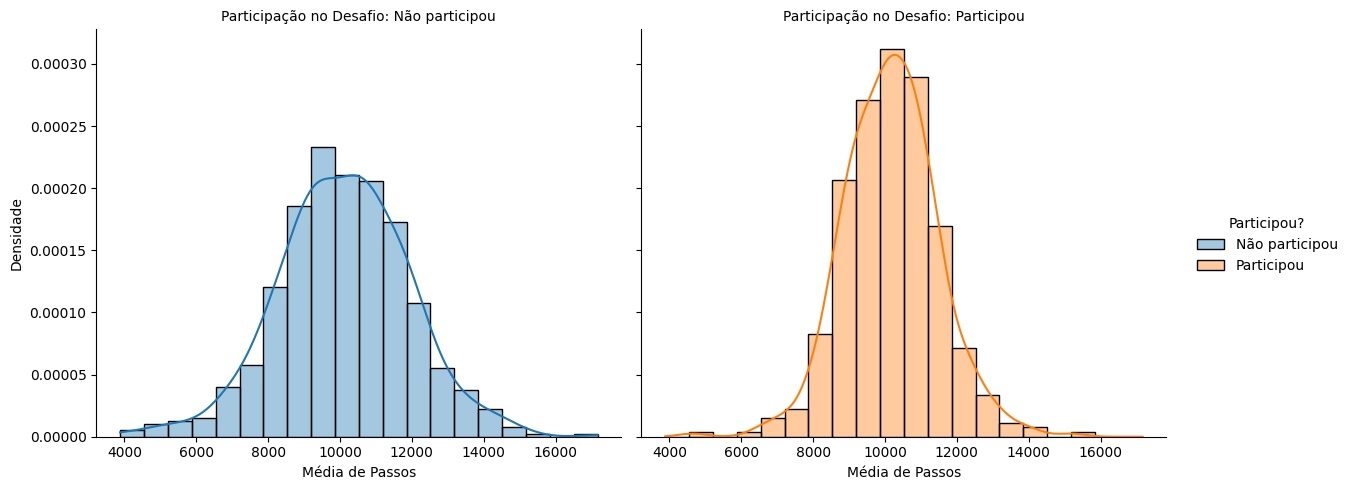

In [28]:
#Verificando o efeito da participação nos passos dados
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

g_passos = sns.displot(
    data=df_user,
    x='steps_mean',
    hue='participa_label',
    col='participa_label',    #Separando em dois gráficos
    kind='hist',              #Definindo o histograma
    kde=True,
    stat='density',           #Transformando 'Contagem' em 'Proporção'
    common_norm=False,        #Tratando cada grupo como 100%
    bins=20,
    palette='tab10',
    alpha=0.4,                #Transparência para ver onde as linhas se cruzam
    height=5,                 #Altura dos gráficos
    aspect=1.2                #Largura dos gráficos
)

g_passos._legend.set_title('Participou?')

g_passos.set_axis_labels('Média de Passos', 'Densidade')
g_passos.set_titles('Participação no Desafio: {col_name}')

file_path = "../outputs/EDA_Bivariate/distplot_passos_participa_facet.png"

plt.savefig(file_path ,bbox_inches='tight')
plt.show()
plt.close()

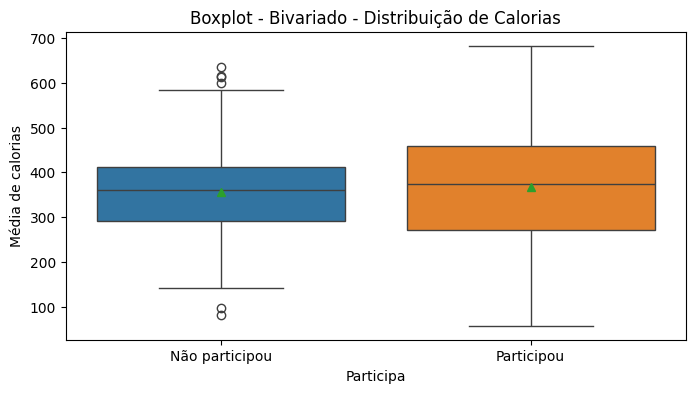

In [29]:
#Entendendo a distribuição dos valores de calorias
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

plt.figure(figsize=(8,4))

sns.boxplot(data=df_user,
    x='participa',
    y='calories_mean',
    showmeans=True,
    hue='participa_label',
    palette='tab10',
    legend=False
)

plt.xlabel('Participa')
plt.ylabel('Média de calorias')
plt.xticks([0,1], ['Não participou', 'Participou'])

plt.title('Boxplot - Bivariado - Distribuição de Calorias')

file_path = '../outputs/EDA_Bivariate/boxplot_bivariado_calorias.png'

plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

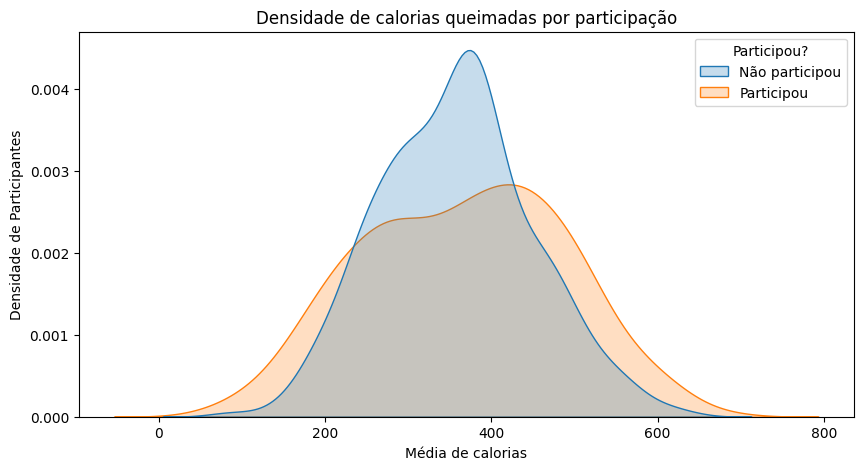

In [30]:
#Analisando a densidade de calorias queimadas de quem participou ou não
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

plt.figure(figsize=(10,5))

sns.kdeplot(data=df_user,
            x='calories_mean',
            hue='participa_label',
            fill=True,
            common_norm=False)
sns.move_legend(plt.gca(), 'upper right', title='Participou?')

plt.title('Densidade de calorias queimadas por participação')
plt.xlabel('Média de calorias')
plt.ylabel('Densidade de Participantes')

file_path = "../outputs/EDA_Bivariate/kde_calorias_participa.png"

plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

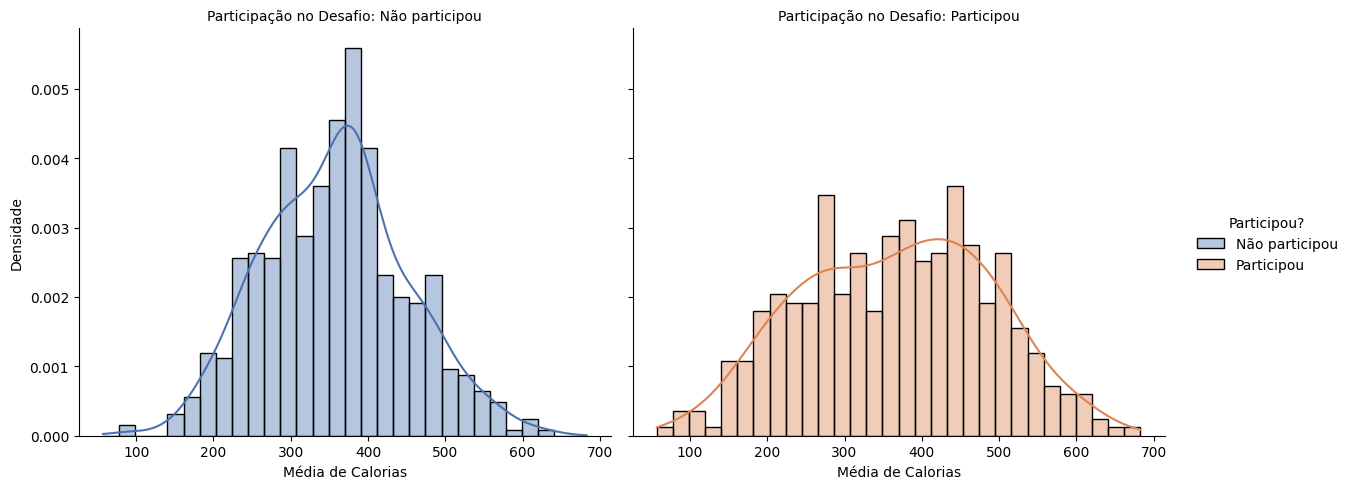

In [31]:
#Analisando a distribuição de calorias queimadas de quem participou ou não
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)

g_calories = sns.displot(
    data=df_user,
    x='calories_mean',
    hue='participa_label',
    col='participa_label',
    kind='hist',
    kde=True,
    stat='density',     #Transformando 'Contagem' em 'Proporção'
    common_norm=False,  #Tratando cada grupo como 100%
    bins=30,
    palette='deep',
    alpha=0.4,          #Transparência para ver onde as linhas se cruzam
    height=5,           #Altura dos gráficos
    aspect=1.2          #Largura dos gráficos
)
g_calories._legend.set_title('Participou?')

g_calories.set_axis_labels('Média de Calorias', 'Densidade')
g_calories.set_titles('Participação no Desafio: {col_name}')

file_path = "../outputs/EDA_Bivariate/distplot_passos_participa_facet.png"

plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()

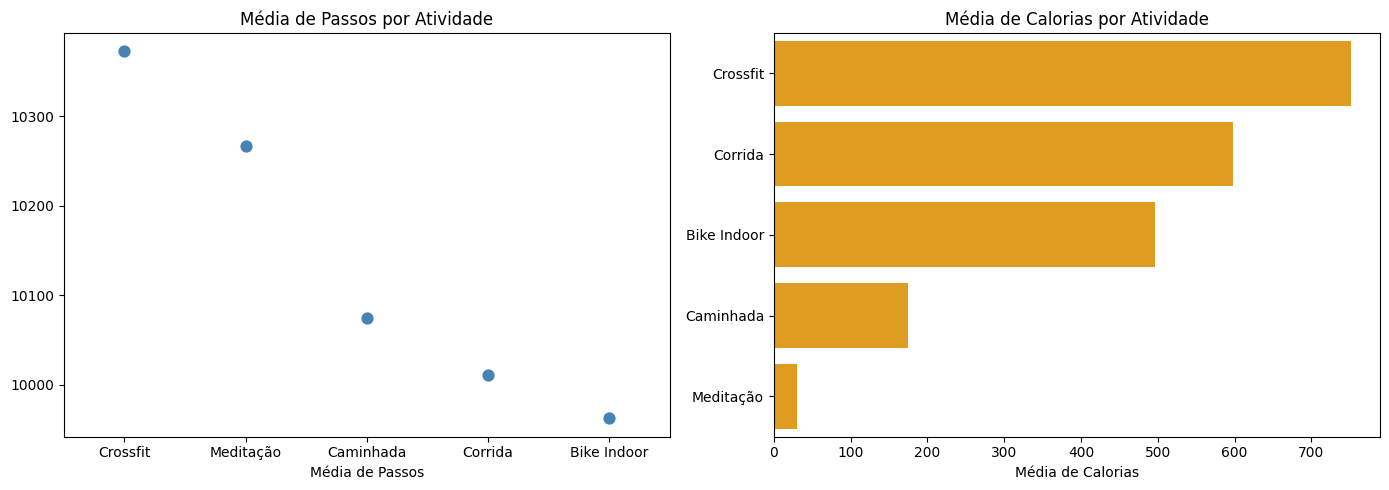

In [32]:
#Agregando atividades com maiores médias de passos e calorias
act_stats = df_activities_full.groupby('activity_type').agg(
    steps_mean=('steps', 'mean'),
    calories_mean=('calories_burned', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Gráfico de média de passos por atividade
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)
sns.pointplot(
    data=act_stats.sort_values('steps_mean', ascending=False),
    x='activity_type',
    y='steps_mean',
    ax=axes[0],
    color='steelblue',
    linestyles='none'
)

axes[0].set_title('Média de Passos por Atividade')
axes[0].set_xlabel('Média de Passos')
axes[0].set_ylabel('')

#Média de calorias por atividade
sns.barplot(
    data=act_stats.sort_values('calories_mean', ascending=False),
    y='activity_type',
    x='calories_mean',
    ax=axes[1],
    color='orange',
)

axes[1].set_title('Média de Calorias por Atividade')
axes[1].set_xlabel('Média de Calorias')
axes[1].set_ylabel('')

file_path = "../outputs/EDA_Bivariate/barplot_atividade_steps_calorias.png"

plt.tight_layout()
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()



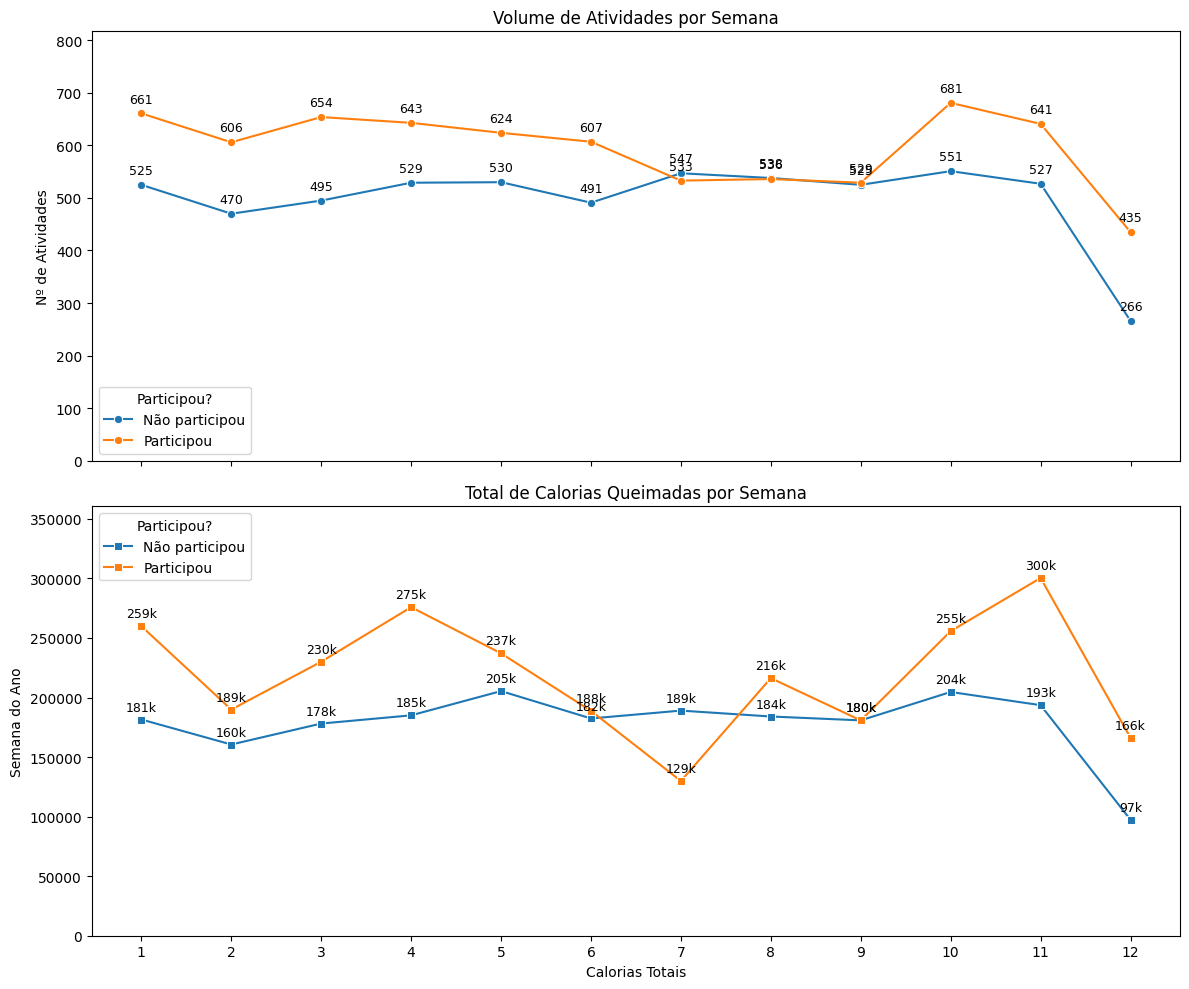

In [ ]:
#Criando a coluna de label dos participantes
df_activities_full['participa_label'] = df_activities_full['participa'].map({True: 'Participou', False: 'Não participou'})

#Convertendo a coluna de data para datatime e extraindo o mês
df_activities_full['date'] = pd.to_datetime(df_activities_full['date'])
df_activities_full['month'] = df_activities_full['date'].dt.month

#Agregando semanas com mais densidade de participações e calorias
monthly_stats = df_activities_full.groupby(['month', 'participa_label']).agg(
    n_atividades=('activity_id', 'count'),
    total_calorias=('calories_burned', 'sum')
).reset_index()

#Tamanho dos gráficos
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

#Densidade de atividades ao longo das semanas
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)
sns.lineplot(
    data=monthly_stats,
    x='month',
    y='n_atividades',
    hue='participa_label',
    ax=axes[0],
    marker='o',
    palette='tab10'
)

axes[0].set_title('Volume de Atividades por Semana')
axes[0].set_xlabel('Semana')
axes[0].set_ylabel('Nº de Atividades')
axes[0].legend(title='Participou?')

#Densidade de calorias ao longo das semanas
sns.lineplot(
    data=monthly_stats,
    x='month',
    y='total_calorias',
    hue='participa_label',
    ax=axes[1],
    marker='s',
    palette='tab10'
)

axes[1].set_title('Total de Calorias Queimadas por Semana')
axes[1].set_xlabel('Calorias Totais')
axes[1].set_ylabel('Semana do Ano')
axes[1].legend(title='Participou?')

#Ajustando eixo X do gráfico de 1 a 12 (Meses)
axes[1].set_xticks(range(1, 13))

#Adicionando números aos pontos do gráfico
for idx, row in monthly_stats.iterrows():
    # Nº de atividades
    axes[0].text(
        x=row['month'], 
        y=row['n_atividades'] + 15, # +15 para o texto ficar um pouco acima do ponto
        s=f"{int(row['n_atividades'])}", 
        color='black', 
        fontsize=9, 
        ha='center', 
        va='bottom'
    )
    # Calorias em formato "k"
    axes[1].text(
        x=row['month'], 
        y=row['total_calorias'] + 5000, 
        s=f"{int(row['total_calorias']/1000)}k", 
        color='black', 
        fontsize=9, 
        ha='center', 
        va='bottom'
    )

# Adiciona um limite extra no Y para os números não cortarem no topo
axes[0].set_ylim(0, monthly_stats['n_atividades'].max() * 1.2)
axes[1].set_ylim(0, monthly_stats['total_calorias'].max() * 1.2)

file_path = "../outputs/EDA_Bivariate/lineplot_semanas_densidade.png"

plt.tight_layout()
plt.savefig(file_path, bbox_inches='tight')
plt.show()
plt.close()


Hipótese 2: *Desafios aumentam retenção:*
    Usuários que participam de desafios apresentam maior frequência de uso do aplicativo ao longo do tempo

        Métricas associadas:
            Média de de visitas semanais à academia;
            Número de check-ins no app;
            Número de registros de atividade por usuário.

In [34]:
#Hipótese 2:

# Agrupando a base 'weekly_visits' para ter a média de visitas por usuário
avg_visits = weekly_visits.groupby('user_id')['weekly_gym_visits'].mean().reset_index()

# Renomeando a coluna para não confundir com a original
avg_visits.rename(columns={'weekly_gym_visits': 'avg_weekly_visits'}, inplace=True)

# Juntando (Merge) essa nova informação com o nosso df_user
df_user = df_user.merge(avg_visits, on='user_id', how='left')

# Preenchendo quem não tem visitas com 0 (Tratamento de Nulos)
df_user['avg_weekly_visits'] = df_user['avg_weekly_visits'].fillna(0)

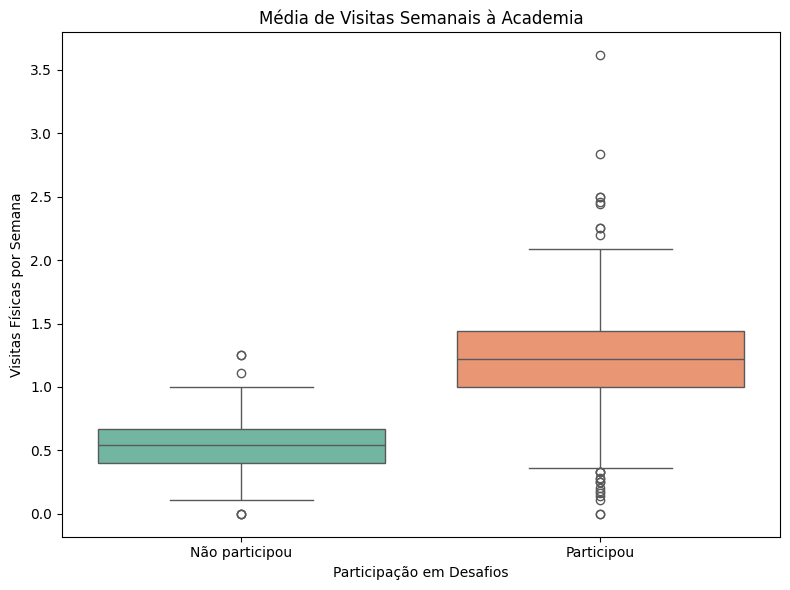

In [39]:
#Entendendo a frequência dos participantes

#Tamanho da figura
plt.figure(figsize=(8, 6))

#Criando o Boxplot
os.makedirs('../outputs/EDA_Bivariate', exist_ok=True)
sns.boxplot(
    data=df_user,
    x='participa_label',
    y='avg_weekly_visits',
    hue='participa_label',
    palette='Set2',
    legend=False
)

plt.title('Média de Visitas Semanais à Academia')
plt.xlabel('Participação em Desafios')
plt.ylabel('Visitas Físicas por Semana')

file_path = "../outputs/EDA_Bivariate/lineplot_semanas_densidade.png"

plt.tight_layout()
plt.savefig('../outputs/EDA_Bivariate/boxplot_visitas_fisicas.png', bbox_inches='tight')
plt.show()
plt.close()

Hipótese 3: *Desafios estimulam mais atividade física:* Usuários que participam de um maior número de desafios apresentam maior nível de engajamento físico.

        Métricas associadas:
            Steps médios por número de desafios;
            Calorias queimadas por número de desafios.

In [35]:
#Hipótese 3:

Hipótese 4: *Usuários que participam de mais desafios apresentam maior nível de engajamento:*

    A probabilidade de participação em desafios varia de acordo com características do usuário.
        Métricas associadas:
            Taxa de participação por grupo de idade;
            Taxa de participação por gênero;
            Taxa de participação pela distância da acadêmia.

In [36]:
#Hipótese 4:

Hipótese 5: *Desafios geram mais frequência de uso:*

    O tipo de atividade do desafio influencia a taxa de participação dos usuários.
        Métricas associadas:
            Número de participantes por tipo de atividade;
            Média de participação por desafio.

In [37]:
#Hipótese 5:

Hipótese 6: Usuários com maior nível de atividade:

    Usuários apresentam maior volume de atividades durante o período de participação em desafios.
        Métricas associadas:
            Número de atividades durante período do desafio.

In [38]:
#Hipótese 6: